# Detecção de Padrões de Fraude com Clustering (Aprendizado Não Supervisionado)
## Fase 1 — K-means
### Baseline: o comportamento transacional, sozinho, já separa fraude de legítimo?

**Contexto de negócio:** áreas de prevenção a fraude e compliance frequentemente dependem de regras fixas (ex.: "valor > X e fora do horário comercial = flag"). Este projeto testa uma pergunta diferente: **sem usar o rótulo de fraude em nenhum momento do treinamento**, o clustering consegue, sozinho, descobrir uma estrutura nos dados que já concentre a fraude em poucos grupos?

Se a resposta for sim (mesmo que parcialmente), isso vira um sinal de alto valor: um jeito de priorizar transações para revisão manual ou regras de monitoramento, **sem depender de um modelo supervisionado já treinado com histórico de fraude confirmada** (útil em cenários de fraude nova, ainda sem rótulo confiável).

**Regra do jogo:** a coluna `is_fraud` é retirada dos dados antes do clustering e só é revisitada no final, para validação externa — nunca para treinar.

### Fonte:
Fraud Detection
Synthetic Fraud: Imbalanced Classification & Missing Data
dataset: https://www.kaggle.com/datasets/waddahali/fraud-detection

Brasília - 11/09/2026

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

#set seed
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2 - Carregamento e exploração incial

In [6]:
# carregar o dataset

df_fraud = pd.read_csv("./data/fraud.csv", encoding = "utf-8") 
df_fraud.shape

(7000, 13)

In [7]:
df_fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   transaction_amount    6440 non-null   float64
 1   hour_of_day           6650 non-null   float64
 2   is_weekend            6860 non-null   float64
 3   num_items             6790 non-null   float64
 4   customer_age          6160 non-null   float64
 5   prev_transactions     6510 non-null   float64
 6   distance_from_home    6300 non-null   float64
 7   device_type           6720 non-null   float64
 8   network_quality       6370 non-null   float64
 9   is_first_transaction  6790 non-null   float64
 10  store_type            6860 non-null   float64
 11  velocity_score        5950 non-null   float64
 12  is_fraud              7000 non-null   int64  
dtypes: float64(12), int64(1)
memory usage: 711.1 KB


In [9]:
df_fraud.describe()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
count,6440.000000,6650.000000,6860.000000,6790.000000,6160.000000,6510.000000,6300.000000,6720.000000,6370.000000,6790.000000,6860.000000,5950.000000,7000.000000
mean,100.014648,2.200902,0.108601,2.977320,36.200811,4.457604,24.830735,0.698810,74.094739,0.095876,0.286735,5.007450,0.103000
std,49.091009,0.677906,0.311160,1.712444,13.283996,4.881635,24.314751,0.776802,18.003855,0.294443,0.452270,2.007633,0.303981
min,1.000000,1.000000,0.000000,0.000000,18.000000,0.000000,0.004282,0.000000,0.477174,0.000000,0.000000,-1.853966,0.000000
25%,65.711569,2.000000,0.000000,2.000000,25.244168,1.000000,7.387315,0.000000,61.586731,0.000000,0.000000,3.697990,0.000000
50%,99.482201,2.000000,0.000000,3.000000,35.361187,3.000000,17.321496,1.000000,75.306346,0.000000,0.000000,4.992099,0.000000
75%,132.897923,3.000000,0.000000,4.000000,45.500089,6.000000,34.857859,1.000000,88.253574,0.000000,1.000000,6.342852,0.000000
max,296.311885,3.000000,1.000000,13.000000,80.000000,40.000000,224.699757,2.000000,100.000000,1.000000,1.000000,12.659564,1.000000


In [8]:
df_fraud.isnull().sum().sort_values(ascending = False)

velocity_score          1050
customer_age             840
distance_from_home       700
network_quality          630
transaction_amount       560
prev_transactions        490
hour_of_day              350
device_type              280
num_items                210
is_first_transaction     210
is_weekend               140
store_type               140
is_fraud                   0
dtype: int64

## 3 - Data Cleaning & Data Wrangling

### 3.1.1 - Limpeza de dados ausentes

In [10]:
# Extraindo o total de valores ausentes por coluna
valores_ausentes = df_fraud.isnull().sum().sort_values(ascending = False)

In [11]:
print(valores_ausentes)

velocity_score          1050
customer_age             840
distance_from_home       700
network_quality          630
transaction_amount       560
prev_transactions        490
hour_of_day              350
device_type              280
num_items                210
is_first_transaction     210
is_weekend               140
store_type               140
is_fraud                   0
dtype: int64


In [12]:
# Calculando o percentual de valores ausentes
valores_ausentes_percent = valores_ausentes[valores_ausentes > 0] / df_fraud.shape[0] 

print(f'{valores_ausentes_percent * 100} %')

velocity_score          15.0
customer_age            12.0
distance_from_home      10.0
network_quality          9.0
transaction_amount       8.0
prev_transactions        7.0
hour_of_day              5.0
device_type              4.0
num_items                3.0
is_first_transaction     3.0
is_weekend               2.0
store_type               2.0
dtype: float64 %


In [13]:
df_fraud.head(5)

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
0,161.363691,3.0,0.0,2.0,18.000000,2.0,26.539742,1.0,48.403937,0.0,0.0,3.718296,0
1,116.202851,1.0,1.0,4.0,26.285818,2.0,50.714402,NaN,76.144979,0.0,0.0,4.951272,0
2,1.000000,2.0,0.0,5.0,18.000000,NaN,9.467935,0.0,67.600316,0.0,0.0,4.556043,0
3,48.780618,2.0,0.0,3.0,44.471190,NaN,41.077068,0.0,94.825526,0.0,0.0,6.918437,0
4,NaN,3.0,0.0,4.0,38.733609,8.0,NaN,2.0,100.000000,0.0,1.0,5.535335,1


Imputar pela mediana funciona bem para modelos supervisionados, mas para clustering tem um efeito colateral que regressão não tem: você está empilhando centenas de pontos exatamente no mesmo valor, criando uma densidade artificial ali. Isso é particularmente perigoso na Fase 3, quando você for usar DBSCAN — um algoritmo baseado em densidade pode literalmente formar um cluster falso só porque 1.050 linhas de velocity_score

A correção mais simples é trocar "preencher todos com um valor fixo" por sortear valores reais da própria coluna para preencher os ausentes — em vez de empilhar tudo no mesmo ponto (a mediana).
Cada ausente recebe um valor diferente, sorteado da distribuição real daquela variável. Isso evita a densidade artificial sem acrescentar a complexidade de um imputador baseado em regressão

In [15]:
# Random sample imputation
# Imputação por amostragem aleatória da distribuição observada:
# em vez de um valor fixo (mediana), cada ausente recebe um valor

np.random.seed(42)  # reprodutibilidade

#Monta a lista de colunas que vamos tratar — todas, exceto is_fraud.
colunas_features = [c for c in df_fraud.columns if c != 'is_fraud'] #Um loop que passa por cada coluna, uma de cada vez

for coluna in colunas_features:
    valores_observados = df_fraud[coluna].dropna().values # Pega só os valores reais daquela coluna, descartando os NaN
    mascara_ausente = df_fraud[coluna].isnull() # Cria uma máscara booleana (True/False) marcando onde estão os valores ausentes naquela coluna
    n_ausentes = mascara_ausente.sum() # Como True vale 1 e False vale 0, somar a máscara conta quantos ausentes existem
    
    if n_ausentes > 0: # Só executa o sorteio se realmente houver algo pra preencher
        valores_sorteados = np.random.choice(valores_observados, size=n_ausentes, replace=True)
        df_fraud.loc[mascara_ausente, coluna] = valores_sorteados # Usa a máscara para localizar exatamente as linhas ausentes daquela coluna e substitui pelos valores sorteados, na ordem.

# Conferindo que não sobrou nenhum valor ausente
print(df_fraud.isnull().sum().sum())

0


Em: valores_sorteados = np.random.choice(valores_observados, size=n_ausentes, replace=True)

está o coração da técnica: sorteia n_ausentes valores de dentro de valores_observados, com reposição (replace=True — o mesmo valor real pode ser sorteado mais de uma vez, o que é esperado e correto, já que estamos amostrando da distribuição, não distribuindo valores únicos). O resultado é um array do mesmo tamanho da quantidade de buracos daquela coluna.

In [16]:
df_fraud.isnull().sum().sort_values(ascending = False)

transaction_amount      0
hour_of_day             0
is_weekend              0
num_items               0
customer_age            0
prev_transactions       0
distance_from_home      0
device_type             0
network_quality         0
is_first_transaction    0
store_type              0
velocity_score          0
is_fraud                0
dtype: int64

### 3.1.2 - Tratamento de variáveis binárias e categóricas


#### Seleção de Variáveis para o Clustering

- **Decisão: excluir variáveis binárias/categóricas nominais do cálculo de
  distância, sem descartá-las do dataset.**
- **Variáveis fora do clustering:** `is_weekend`, `device_type`,
  `is_first_transaction`, `store_type`.
- **Variáveis no clustering:** as contínuas (`transaction_amount`, `num_items`,
  `customer_age`, `prev_transactions`, `distance_from_home`, `network_quality`,
  `velocity_score`) + `hour_of_day`, mantida por ter ordem natural (manhã 
  tarde < noite).
- **Justificativa:** o K-Means usa distância Euclidiana, pensada para variáveis
  contínuas. Misturada com binárias/nominais, o salto discreto de 0 para 1
  carrega peso desproporcional na distância — foi o que explicou o achado da
  Fase 1 (`store_type` e `is_first_transaction` dominando a separação dos
  clusters). `device_type` é ainda mais problemática: é categórica nominal
  (0=Mobile, 1=Desktop, 2=Tablet), sem ordem real entre os valores, então
  tratá-la como número numa distância assume uma ordem que não existe.
- **As colunas excluídas não são descartadas:** continuam em `df_fraud` para
  caracterizar e validar os clusters depois de formados (ex.: "o cluster X
  concentra X% de clientes na primeira transação, citada na documentação do
  dataset como sinal de fraude").
- **Alternativa não usada:** distância de Gower trataria cada tipo de variável
  de forma nativa, mas exige biblioteca extra e mais complexidade — fica como
  opção futura, não como abordagem atual.

In [30]:
# Colunas binárias/categóricas nominais: ficam fora do cálculo de distância,
# mas continuam em df_fraud para caracterizar os clusters depois
colunas_categoricas = ['is_weekend', 'device_type', 'is_first_transaction', 'store_type', 'hour_of_day']

# Colunas contínuas (+ hour_of_day, que é ordinal): essas vão para o clustering
colunas_continuas = [c for c in colunas_features if c not in colunas_categoricas]

print(colunas_continuas)

['transaction_amount', 'num_items', 'customer_age', 'prev_transactions', 'distance_from_home', 'network_quality', 'velocity_score']


### 3.1.3 - Outliers

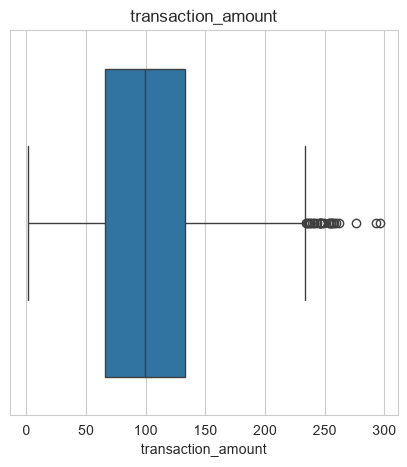

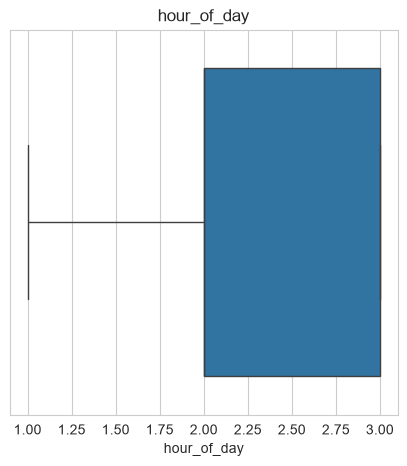

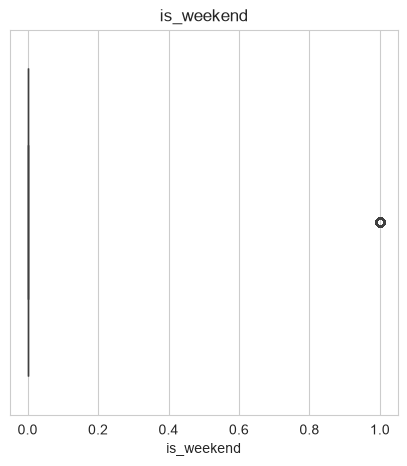

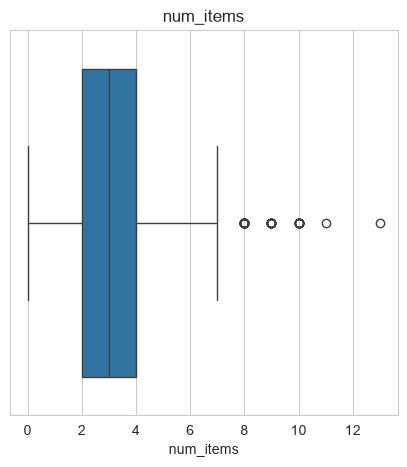

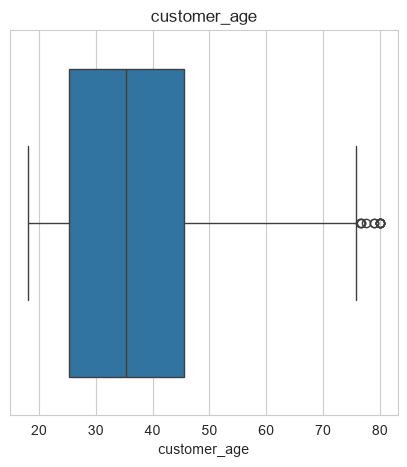

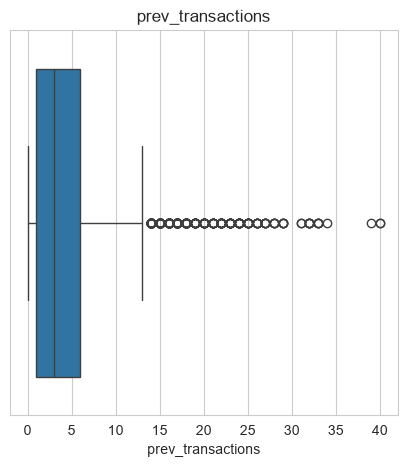

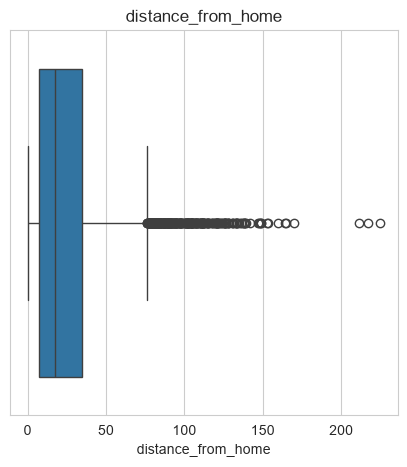

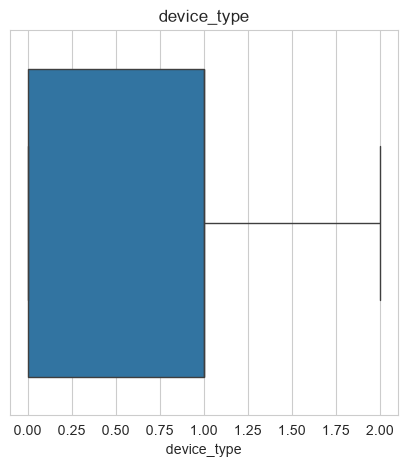

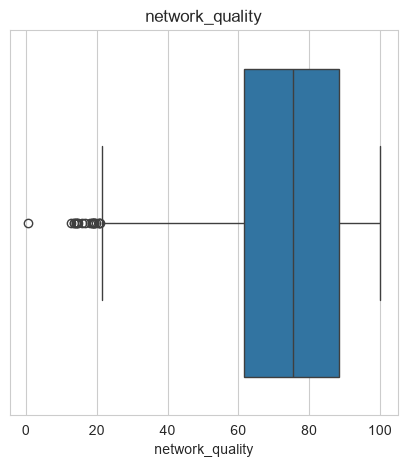

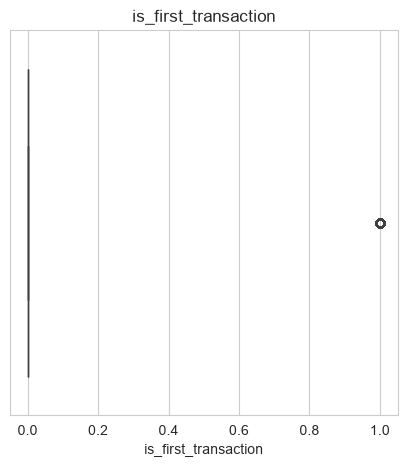

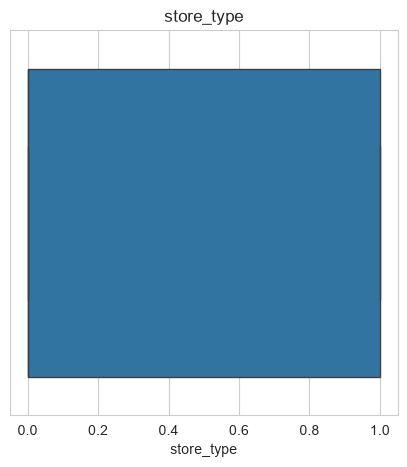

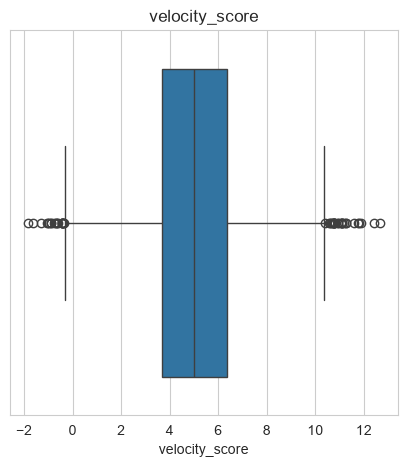

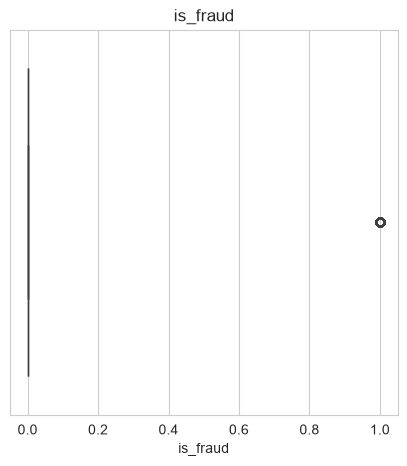

In [18]:
# Visualizando outliers para cada variável no DataFrame
for column in df_fraud.columns:
    if df_fraud[column].dtype in ['int64', 'float64']:  
        plt.figure(figsize = (5, 5))
        sns.boxplot(x = df_fraud[column])
        plt.title(column)
        plt.show()

In [19]:
df_fraud.describe()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,100.072511,2.203143,0.108571,2.976000,36.242835,4.457429,24.742412,0.698000,74.138486,0.096143,0.286857,5.003841,0.103000
std,49.176533,0.678190,0.311123,1.710927,13.268708,4.887377,24.205429,0.777007,18.008230,0.294808,0.452327,2.007006,0.303981
min,1.000000,1.000000,0.000000,0.000000,18.000000,0.000000,0.004282,0.000000,0.477174,0.000000,0.000000,-1.853966,0.000000
25%,65.964220,2.000000,0.000000,2.000000,25.307454,1.000000,7.286227,0.000000,61.568018,0.000000,0.000000,3.685604,0.000000
50%,99.482201,2.000000,0.000000,3.000000,35.375481,3.000000,17.257035,1.000000,75.426263,0.000000,0.000000,5.000561,0.000000
75%,132.955109,3.000000,0.000000,4.000000,45.581478,6.000000,34.845907,1.000000,88.309628,0.000000,1.000000,6.358915,0.000000
max,296.311885,3.000000,1.000000,13.000000,80.000000,40.000000,224.699757,2.000000,100.000000,1.000000,1.000000,12.659564,1.000000


## 4 - Correlações

In [27]:
df_fraud.corr()

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud
transaction_amount,1.000000,0.006116,0.016748,-0.009465,0.020005,0.008580,0.004547,-0.009518,-0.005358,0.008909,-0.005102,-0.032080,0.013595
hour_of_day,0.006116,1.000000,-0.013129,-0.003063,0.002166,0.009550,-0.009341,-0.002320,-0.004629,-0.010516,0.002836,-0.013617,-0.014184
is_weekend,0.016748,-0.013129,1.000000,-0.005304,0.003764,-0.008423,-0.001388,0.007400,-0.014781,-0.009453,0.018263,0.003919,-0.001934
num_items,-0.009465,-0.003063,-0.005304,1.000000,0.005239,0.002390,0.002809,0.010024,0.017004,0.005142,-0.016027,0.011420,-0.018323
customer_age,0.020005,0.002166,0.003764,0.005239,1.000000,-0.000859,-0.008622,-0.012968,-0.015286,0.009329,0.001676,-0.000780,-0.012449
prev_transactions,0.008580,0.009550,-0.008423,0.002390,-0.000859,1.000000,-0.007469,-0.001241,-0.016188,0.011220,0.008110,-0.004730,0.000980
distance_from_home,0.004547,-0.009341,-0.001388,0.002809,-0.008622,-0.007469,1.000000,-0.008631,0.006180,-0.007091,-0.020517,-0.011273,0.043536
device_type,-0.009518,-0.002320,0.007400,0.010024,-0.012968,-0.001241,-0.008631,1.000000,-0.012253,-0.011074,-0.005929,-0.003524,-0.033426
network_quality,-0.005358,-0.004629,-0.014781,0.017004,-0.015286,-0.016188,0.006180,-0.012253,1.000000,0.000655,0.000602,0.010940,0.000806
is_first_transaction,0.008909,-0.010516,-0.009453,0.005142,0.009329,0.011220,-0.007091,-0.011074,0.000655,1.000000,0.021370,0.021954,0.013840


In [31]:
df_fraud[colunas_continuas].corr()

,transaction_amount,num_items,customer_age,prev_transactions,distance_from_home,network_quality,velocity_score
transaction_amount,1.000000,-0.009465,0.020005,0.008580,0.004547,-0.005358,-0.032080
num_items,-0.009465,1.000000,0.005239,0.002390,0.002809,0.017004,0.011420
customer_age,0.020005,0.005239,1.000000,-0.000859,-0.008622,-0.015286,-0.000780
prev_transactions,0.008580,0.002390,-0.000859,1.000000,-0.007469,-0.016188,-0.004730
distance_from_home,0.004547,0.002809,-0.008622,-0.007469,1.000000,0.006180,-0.011273
network_quality,-0.005358,0.017004,-0.015286,-0.016188,0.006180,1.000000,0.010940
velocity_score,-0.032080,0.011420,-0.000780,-0.004730,-0.011273,0.010940,1.000000


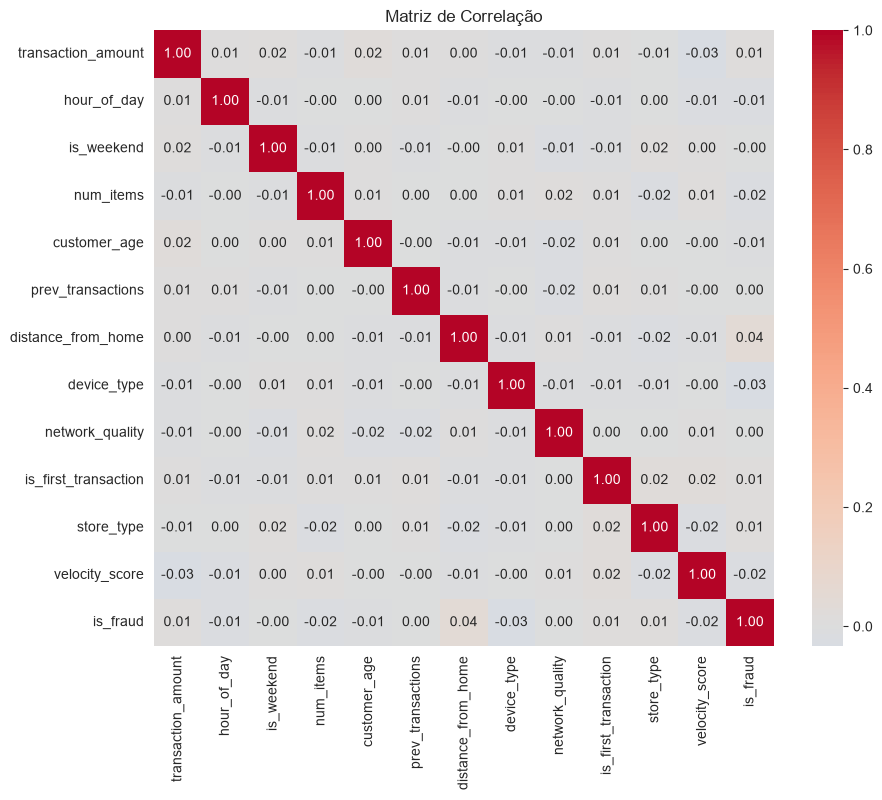

In [22]:
# Calculando a matriz de correlação primeiro
correlation_matrix = df_fraud.corr()

# Plot
plt.figure(figsize = (10, 8))
sns.heatmap(correlation_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Matriz de Correlação')
plt.show()

## Tratamento de Dados — Decisões e Justificativas

### Valores Ausentes (56,1% das linhas afetadas)
- **Técnica escolhida:** Random Sample Imputation (amostragem aleatória da
  distribuição observada de cada coluna), com `seed = 42` para reprodutibilidade.
- **Por que não a mediana:** imputar um valor fixo (mediana) empilharia centenas
  de pontos idênticos em cada coluna afetada, criando densidade artificial —
  um problema direto para algoritmos baseados em densidade (DBSCAN, Fase 3).
  O sorteio preserva a distribuição real da variável sem esse efeito colateral.
- **Por que não KNN/MICE:** essas técnicas exploram correlação entre variáveis
  para imputar com mais precisão — mas a matriz de correlação já mostrou que
  as 12 features são praticamente independentes entre si, então o ganho não
  compensaria a complexidade extra.

### Outliers
- **Decisão: manter todos os outliers, sem remoção ou cap.**
- **Justificativa:** este é um projeto de detecção de fraude — a própria
  documentação do dataset associa valor alto de `transaction_amount`, horário
  incomum e cliente novo a maior probabilidade de fraude. O outlier aqui é
  candidato a sinal relevante, não ruído a limpar. Removê-lo descartaria
  exatamente o que a Fase 3 (DBSCAN tratando fraude como ruído/anomalia)
  precisa encontrar.
- **Mitigação da escala, sem remover dados:** troca de `StandardScaler` por
  `RobustScaler` — usa mediana e IQR (em vez de média e desvio padrão), então
  a padronização não é distorcida pelos valores extremos, mas o ponto extremo
  continua disponível na análise.
- **Nota:** `velocity_score` apresenta outliers nas duas pontas, incluindo
  valores negativos (mín. -1,85) — não corrigido agora, mas registrado para
  revisão caso apareça como cluster isolado nas próximas fases.

# 5 - Separando features e padronizando os dados

### Padronização (Scaling)

- **Decisão: `RobustScaler` no lugar de `StandardScaler`.**
- **Justificativa:** na etapa de outliers, decidimos mantê-los sem remoção
  ou cap, já que podem ser sinal de fraude (valor de transação alto, distância
  incomum de casa etc.). O `StandardScaler` usa média e desvio padrão — ambos
  sensíveis a valores extremos — então padronizar com ele distorceria a escala
  de todas as variáveis a partir dos próprios outliers que decidimos preservar,
  anulando o cuidado tomado na etapa anterior.
- **Como o `RobustScaler` resolve isso:** usa mediana e IQR em vez de média e
  desvio padrão, que não se deixam influenciar pelos extremos — a escala fica
  estável para a maioria dos dados, e o outlier continua presente e disponível
  para a análise (importante para a Fase 3, com DBSCAN).
- **Efeito esperado nos dados escalados:** valores dentro do IQR ficam
  aproximadamente entre -1 e 1; outliers aparecem com valores bem maiores
  (ex.: 4, 5, 6+) — isso é esperado e não indica erro no código.

In [32]:
from sklearn.preprocessing import RobustScaler

X = df_fraud[colunas_continuas]  # apenas as variáveis contínuas + hour_of_day
y_true = df_fraud['is_fraud']    # guardado, não usado no treinamento

scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=colunas_continuas)
X_scaled.head()

,transaction_amount,num_items,customer_age,prev_transactions,distance_from_home,network_quality,velocity_score
0,0.923730,-0.5,-0.857032,-0.2,0.336822,-1.010497,-0.479654
1,0.249596,0.5,-0.448340,-0.2,1.213997,0.026876,-0.018437
2,-1.470084,1.0,-0.857032,0.2,-0.282627,-0.292651,-0.166280
3,-0.756843,0.0,0.448639,-0.4,0.864307,0.725434,0.717416
4,-0.474853,0.5,0.165637,1.0,-0.094071,0.918933,0.200042


In [34]:
# Lista para armazenar o SSE
sse = []

# Range de valores de k a serem testados
k_range = range(1, 11)



In [35]:
# Testando os valores
for k in k_range:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

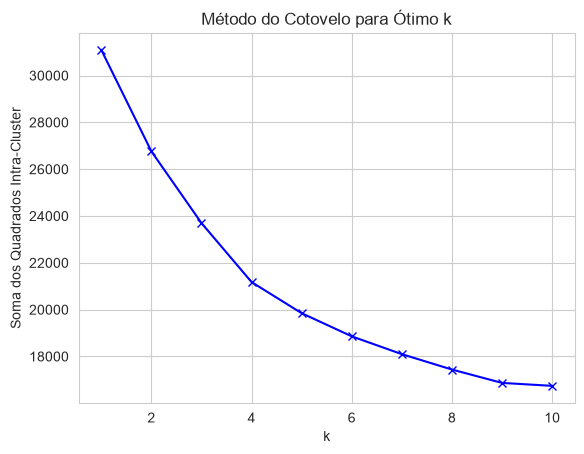

In [36]:
# Plot
plt.plot(k_range, sse, 'bx-')
plt.xlabel('k')
plt.ylabel('Soma dos Quadrados Intra-Cluster')
plt.title('Método do Cotovelo para Ótimo k')
plt.show()

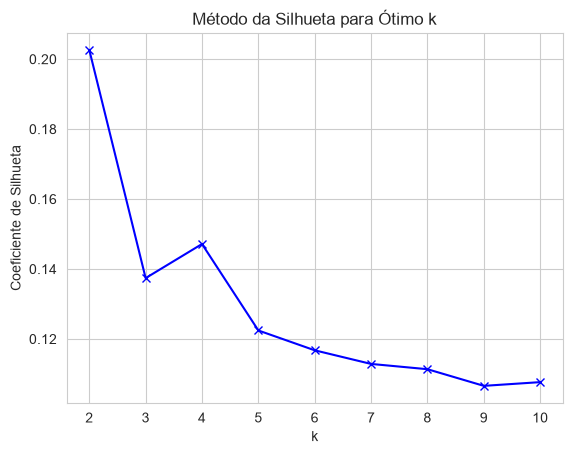

In [ ]:
# Lista para o Silhouette score
sil_score = []

# Loop pelo range de valores de k a serem testados
for k in k_range:
    kmeans = KMeans(n_clusters = k)
    kmeans.fit(X_scaled)
    
    # Silhouette score não é definido para k = 1, então filtramos
    if k != 1:
        sil_score.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot
plt.plot(k_range[1:], sil_score, 'bx-')
plt.xlabel('k')
plt.ylabel('Coeficiente de Silhueta')
plt.title('Método da Silhueta para Ótimo k')
plt.show()

## 6 - Construção da Primeira Versão do Modelo de Clusterização

In [39]:
# Modelo com 2 clusters
modelo_kmeans = KMeans(n_clusters = 2, random_state = 42, n_init = 10)
# n_init=10 o KMeans testa várias inicializações de centróide e fica com a melhor; sem fixar isso, 
# o resultado pode variar entre execuções mesmo com random_state

# Treina o modelo e salva o resultado em uma coluna do dataframe original
df_fraud['cluster'] = modelo_kmeans.fit_predict(X_scaled)

# Amostra aleatória de dados
df_fraud.sample(10)

,transaction_amount,hour_of_day,is_weekend,num_items,customer_age,prev_transactions,distance_from_home,device_type,network_quality,is_first_transaction,store_type,velocity_score,is_fraud,cluster
800,66.592796,2.0,0.0,2.0,20.779046,1.0,42.203657,0.0,56.583141,0.0,0.0,5.648646,1,1
5076,117.383824,2.0,0.0,3.0,24.989455,0.0,14.442243,1.0,75.315463,0.0,1.0,6.365809,0,1
6319,83.043886,2.0,0.0,2.0,46.295843,17.0,20.212872,0.0,93.058901,0.0,1.0,5.552196,1,0
5573,126.825492,2.0,0.0,6.0,18.000000,2.0,60.161957,1.0,56.786025,0.0,0.0,5.794929,0,1
586,67.531759,2.0,1.0,5.0,35.367982,4.0,8.276216,2.0,100.000000,0.0,0.0,7.995118,0,1
996,89.816312,2.0,0.0,0.0,40.110798,6.0,25.945444,1.0,62.466838,0.0,1.0,6.671230,0,1
6425,39.612030,1.0,0.0,1.0,30.559531,0.0,9.361595,2.0,90.201013,0.0,0.0,2.793415,0,1
3836,43.697302,3.0,0.0,2.0,29.080283,2.0,17.098041,1.0,66.964374,1.0,0.0,6.354999,0,1
4077,201.129512,2.0,0.0,4.0,23.446692,3.0,97.471623,0.0,78.517293,0.0,0.0,3.648505,0,1
408,43.863899,3.0,0.0,1.0,18.000000,5.0,5.457983,1.0,94.626419,0.0,0.0,7.249680,0,1


In [40]:
print('Silhueta final:', round(silhouette_score(X_scaled, df_fraud['cluster']), 4))
df_fraud['cluster'].value_counts()

Silhueta final: 0.2026


cluster
1    5611
0    1389
Name: count, dtype: int64

será que o cluster menor (0, com 19,8% da base) concentra fraude acima da média? Essa é a pergunta de negócio central

In [41]:
tabela_fraude = pd.crosstab(df_fraud['cluster'], y_true, normalize='index') * 100
tabela_fraude.columns = ['% Legítima', '% Fraude']
tabela_fraude['Volume no Cluster'] = df_fraud['cluster'].value_counts().sort_index()
tabela_fraude.round(2)

,% Legítima,% Fraude,Volume no Cluster
cluster,,,
0,89.7,10.3,1389
1,89.7,10.3,5611


confirmar numericamente com ARI e NMI, do mesmo jeito que fizemos antes — mesmo com a diferença visualmente zero, é importante para ficar documentado e não depender só de leitura visual:

In [42]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(y_true, df_fraud['cluster'])
nmi = normalized_mutual_info_score(y_true, df_fraud['cluster'])
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')

Adjusted Rand Index (ARI): -0.0001
Normalized Mutual Information (NMI): 0.0000


### Resultado do K-Means (k=2) — Validação Externa

- **Modelo:** K-Means, k=2 (escolhido por trade-off de interpretabilidade de
  negócio, não pela silhueta pura — ver decisão da etapa de escolha de k).
- **Silhueta interna:** 0,2026 — a mais alta entre todos os k testados,
  confirmando reprodutibilidade do pipeline.
- **Distribuição:** cluster 0 com 1.389 transações (19,8%), cluster 1 com
  5.611 (80,2%) — assimétrico, mas sem cluster degenerado.
- **Taxa de fraude por cluster:** 10,3% nos dois clusters — idêntica à taxa
  geral da base, sem nenhuma concentração visível.
- **Validação externa:** ARI = -0,0001, NMI = 0,0000 — concordância nula entre
  a partição de clusters e o rótulo real de fraude.
- **Conclusão:** segunda confirmação do mesmo padrão observado na Fase 1 (com
  dataset, features e configuração de escala diferentes), fortalecendo a
  leitura de que a limitação não está na configuração específica do modelo,
  e sim na natureza do problema: K-Means encontra grupos coesos e redondos,
  enquanto fraude se comporta como anomalia rara e dispersa, não como cluster.
  Resultado consistente com a motivação já prevista para a Fase 3 (DBSCAN).

## Fase 2 — DBSCAN

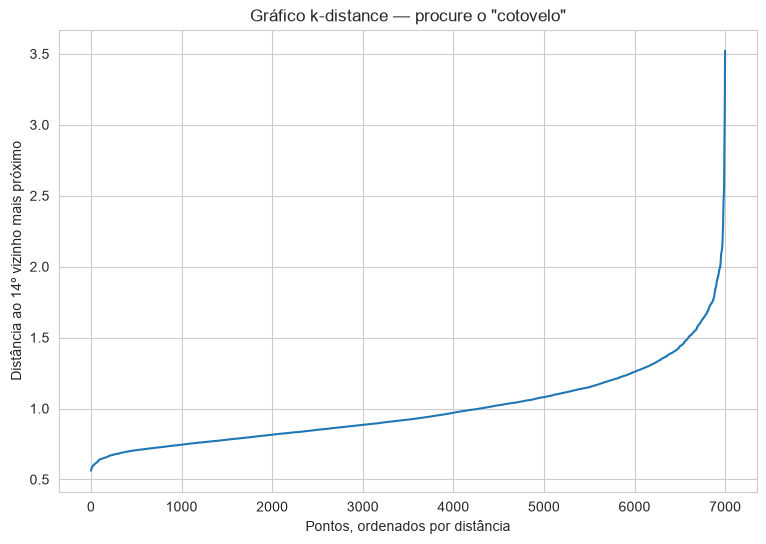

In [43]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 14  # 2 x número de dimensões (7 variáveis contínuas)

# Calcula a distância de cada ponto até seu MIN_SAMPLES-ésimo vizinho mais próximo
vizinhos = NearestNeighbors(n_neighbors=MIN_SAMPLES)
vizinhos_fit = vizinhos.fit(X_scaled)
distancias, indices = vizinhos_fit.kneighbors(X_scaled)

# Pega só a distância ao vizinho mais distante (a última coluna) e ordena crescente
k_distancias = np.sort(distancias[:, -1])

# Plot
plt.figure(figsize=(9, 6))
plt.plot(k_distancias)
plt.xlabel('Pontos, ordenados por distância')
plt.ylabel(f'Distância ao {MIN_SAMPLES}º vizinho mais próximo')
plt.title('Gráfico k-distance — procure o "cotovelo"')
plt.grid(True)
plt.show()

In [46]:
# Testar a hipotese do ponto de inflexão do cotovelo
eps_teste = 1.3
pontos_acima = (k_distancias > eps_teste).sum()
print(f'Pontos com k-distance > {eps_teste}: {pontos_acima} ({pontos_acima/len(k_distancias)*100:.1f}%)')

Pontos com k-distance > 1.3: 841 (12.0%)


In [47]:
from sklearn.cluster import DBSCAN

EPS = 1.3

# Min_samples = 2 x número de dimensões (7 variáveis contínuas)
modelo_dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_fraud['cluster_dbscan'] = modelo_dbscan.fit_predict(X_scaled)

print(df_fraud['cluster_dbscan'].value_counts().sort_index())
print(f"\nTotal de pontos classificados como ruído: {(df_fraud['cluster_dbscan'] == -1).sum()}")

cluster_dbscan
-1     260
 0    6740
Name: count, dtype: int64

Total de pontos classificados como ruído: 260


In [48]:
ruido = df_fraud['cluster_dbscan'] == -1

taxa_fraude_ruido = df_fraud.loc[ruido, 'is_fraud'].mean() * 100
taxa_fraude_normal = df_fraud.loc[~ruido, 'is_fraud'].mean() * 100

print(f'Taxa de fraude DENTRO do ruído (outliers):     {taxa_fraude_ruido:.2f}%')
print(f'Taxa de fraude FORA do ruído (pontos "normais"): {taxa_fraude_normal:.2f}%')

fraudes_totais = df_fraud['is_fraud'].sum()
fraudes_capturadas = df_fraud.loc[ruido, 'is_fraud'].sum()
print(f'\nFraudes reais capturadas no ruído: {fraudes_capturadas} de {fraudes_totais} ({fraudes_capturadas/fraudes_totais*100:.1f}%)')

Taxa de fraude DENTRO do ruído (outliers):     14.23%
Taxa de fraude FORA do ruído (pontos "normais"): 10.15%

Fraudes reais capturadas no ruído: 37 de 721 (5.1%)


In [49]:
# testando varias combinações

resultados = []

for eps_teste in [0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6]:
    for min_samples_teste in [10, 14, 20]:
        modelo = DBSCAN(eps=eps_teste, min_samples=min_samples_teste)
        labels = modelo.fit_predict(X_scaled)
        
        ruido = labels == -1
        n_ruido = ruido.sum()
        
        if n_ruido == 0:
            continue  # nenhum ponto de ruído, não dá para calcular taxa de fraude
        
        taxa_fraude_ruido = y_true[ruido].mean() * 100
        fraudes_capturadas = y_true[ruido].sum()
        recall = fraudes_capturadas / y_true.sum() * 100
        lift = taxa_fraude_ruido / (y_true.mean() * 100)
        
        resultados.append({
            'eps': eps_teste,
            'min_samples': min_samples_teste,
            'n_ruido': n_ruido,
            '%_da_base': round(n_ruido / len(df_fraud) * 100, 1),
            'taxa_fraude_ruido_%': round(taxa_fraude_ruido, 2),
            'recall_%': round(recall, 1),
            'lift': round(lift, 2)
        })

df_resultados = pd.DataFrame(resultados).sort_values('recall_%', ascending=False)
df_resultados

,eps,min_samples,n_ruido,%_da_base,taxa_fraude_ruido_%,recall_%,lift
2,0.9,20,2518,36.0,10.96,38.3,1.06
1,0.9,14,2048,29.3,10.60,30.1,1.03
0,0.9,10,1761,25.2,10.85,26.5,1.05
5,1.0,20,1511,21.6,11.32,23.7,1.10
4,1.0,14,1210,17.3,11.32,19.0,1.10
3,1.0,10,981,14.0,11.72,16.0,1.14
8,1.1,20,890,12.7,12.25,15.1,1.19
7,1.1,14,733,10.5,12.41,12.6,1.21
6,1.1,10,616,8.8,12.99,11.1,1.26
11,1.2,20,520,7.4,13.46,9.7,1.31


In [ ]:
# min_samples = 20 (acima da regra geral de 2x dimensões) — escolhido para
# priorizar cobertura/recall sobre precisão, dentro da faixa considerada
# estatisticamente estável (eps <= 1.3, ver grid search)

EPS = 1.2
MIN_SAMPLES = 20


modelo_dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
df_fraud['cluster_dbscan'] = modelo_dbscan.fit_predict(X_scaled)

print(df_fraud['cluster_dbscan'].value_counts().sort_index())
print(f"\nTotal de pontos classificados como ruído: {(df_fraud['cluster_dbscan'] == -1).sum()}")

cluster_dbscan
-1     520
 0    6480
Name: count, dtype: int64

Total de pontos classificados como ruído: 520


### DBSCAN — Escolha de Parâmetros e Resultado Final

- **Método de escolha do `eps`:** gráfico k-distance (distância ao 14º vizinho
  mais próximo, k = `min_samples` inicial de referência = 2 × número de
  dimensões = 2 × 7 variáveis contínuas). Leitura inicial do cotovelo indicou
  `eps ≈ 1.3–1.7`; a estimativa via contagem de pontos acima do limiar não se
  confirmou 1:1 no resultado real, pois parte dos pontos "não-centrais" foi
  absorvida como Ponto de Borda em vez de virar ruído.
- **Validação sistemática:** grid search com `eps` de 0.9 a 1.6 e `min_samples`
  em {10, 14, 20}, medindo lift (taxa de fraude no ruído ÷ taxa geral) e recall
  (% de fraudes reais capturadas no ruído) para cada combinação.
- **Achado do grid:** o trade-off lift × recall é gradual e contínuo, sem
  "cotovelo" nítido — sinal de que não existe um grupo de fraude fortemente
  isolado no espaço de features usado. Acima de `eps = 1.3`, o volume de
  ruído cai para menos de ~200 pontos e as estimativas de lift ficam
  estatisticamente instáveis (erro-padrão da proporção cresce rápido com
  amostra pequena) — essas combinações foram descartadas por não serem
  confiáveis, não por terem lift baixo.
- **Parâmetros finais: `eps = 1.2`, `min_samples = 20`.** Escolhidos dentro
  da faixa estatisticamente estável (`eps ≤ 1.3`), priorizando cobertura
  (recall quase 2× maior que `eps = 1.3`) em troca de uma perda pequena de
  lift (1,31 vs. 1,38).
- **Resultado:** 520 transações classificadas como ruído (7,4% da base).
  Taxa de fraude dentro do ruído: 13,46% vs. 10,15% fora — lift de 1,31x.
  Recall: 9,7% das fraudes reais (50 de 721) capturadas nesse grupo.
- **Leitura:** primeiro resultado com sinal real do projeto (os dois modelos
  K-Means anteriores deram ARI/NMI ≈ 0). O sinal é moderado, não forte —
  suficiente para validar a hipótese conceitual da Fase 3 (fraude se comporta
  mais como anomalia dispersa do que como cluster coeso), mas insuficiente
  para funcionar como detector de fraude pronto para produção.

## Conclusão Consolidada do Projeto — Clustering Aplicado à Detecção de Fraude

### Pergunta de negócio original
Sem usar o rótulo de fraude em nenhum momento do treinamento, o clustering
consegue, sozinho, descobrir uma estrutura nos dados que concentre a fraude
em poucos pontos — seja como cluster, seja como anomalia?

### Resultados comparados

| Modelo | Configuração | Métrica de validação | Resultado |
|---|---|---|---|
| K-Means | k=3, dataset completo (com variáveis binárias, StandardScaler) | ARI / NMI | ≈ 0,0055 / 0,0002 — nulo |
| K-Means | k=2, dataset refinado (sem binárias, RobustScaler) | ARI / NMI | -0,0001 / 0,0000 — nulo |
| DBSCAN | eps=1.2, min_samples=20 | Lift / Recall | 1,31x / 9,7% — sinal moderado |

### O que aprendemos

1. **Fraude não é um cluster.** Nas duas tentativas de K-Means — com
   configurações de dados bem diferentes entre si — a partição encontrada
   foi estatisticamente independente da fraude real. Isso não foi uma falha
   de ajuste de parâmetro; foi confirmado de forma consistente em dois
   datasets tratados de maneiras distintas, o que fortalece a conclusão em
   vez de enfraquecê-la.

2. **Fraude se comporta um pouco mais como anomalia — mas o sinal é moderado,
   não forte.** O DBSCAN, ao tratar fraude como ruído em vez de forçar um
   cluster, encontrou um grupo 31% mais concentrado em fraude que a base
   geral. É a primeira evidência real de estrutura no projeto, mas cobre
   menos de 10% das fraudes existentes — está longe de ser suficiente
   sozinho como ferramenta de detecção.

3. **A limitação parece estar nos dados, não na técnica.** A matriz de
   correlação mostrou, desde a Fase 1, que as variáveis são praticamente
   independentes entre si (correlações entre -0,03 e 0,02). Isso significa
   que não existe uma combinação natural de variáveis que "aponte" para a
   fraude de forma consistente — o que é coerente com o fato de este ser um
   dataset sintético, gerado com fraude como função de poucas regras
   pontuais (valor alto, horário incomum, cliente novo) somadas a ruído
   aleatório, não como um padrão multivariado coeso.

### Leitura de negócio (o que realmente importa)

Este projeto **não produziu um classificador de fraude pronto para uso** —
e essa é uma conclusão legítima e útil, não um resultado "fraco". Em um
contexto real de compliance/prevenção a fraude, esse é exatamente o tipo de
descoberta que evita que uma área invista tempo e recursos tentando resolver
detecção de fraude com clustering puro, quando o caminho mais adequado seria
um modelo supervisionado (com o rótulo `is_fraud` como target) ou técnicas
de anomalia mais sofisticadas (Isolation Forest, Autoencoders) — hipóteses
para uma eventual continuação do projeto.

O valor entregue aqui foi outro: um teste estruturado e honesto de três
abordagens de aprendizado não supervisionado, incluindo tratamento de dados
justificado em cada etapa (ausência, outliers, seleção de variáveis, escala),
validação externa formal em vez de leitura visual, e um resultado que resiste
à tentação de "forçar" uma conclusão positiva onde os números não sustentam.

### Próximos passos possíveis (fora do escopo deste projeto)
- Testar Isolation Forest ou One-Class SVM como alternativas de detecção de
  anomalia mais adequadas a esse tipo de padrão disperso
- Testar um modelo supervisionado (ex. Regressão Logística, Random Forest)
  usando `is_fraud` como target, para servir de benchmark de quanto sinal
  realmente existe nos dados quando o rótulo é usado diretamente
- Engenharia de features adicionais (combinações entre variáveis, ex.
  valor/histórico de transações) que possam capturar padrões que as
  variáveis originais, isoladas, não capturam